# **Experiment Number:- 06**

Optimize SVM hyperparameters(C,kernel) via grid search on a synthetic 2D dataset

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

#### **Generate a synthetic dataset**
We create a 2D dataset with 2 classes that are not perfectly separable
to make the problem interesting for different kernels.

In [14]:
X, y = make_classification(
    n_samples=300,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    random_state=42,
    n_clusters_per_class=1,
    flip_y=0.1 # Introduce some noise
)

***Split data into training and testing sets***

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

**Define the hyperparameter grid**

In [16]:
param_grid = {
    'C': [0.1, 1, 10, 100],  # Regularization parameter
    'kernel': ['linear', 'rbf', 'poly'],  # Kernel type
    'gamma': ['scale', 'auto'] # Kernel coefficient (for 'rbf' and 'poly')
}

**create an SVM classifier instance**

In [17]:
svc = SVC()

We set up GridSearchCV to test all combinations of hyperparameters. \
cv=5 means 5-fold cross-validation. \
n_jobs=-1 uses all available CPU cores to speed up the process.

In [18]:
grid_search = GridSearchCV(
    estimator=svc,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    verbose=2 # Shows progress
)

In [19]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


GridSearchCV(cv=5, estimator=SVC(), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10, 100], 'gamma': ['scale', 'auto'],
                         'kernel': ['linear', 'rbf', 'poly']},
             verbose=2)

In [20]:
print(f"Best Hyperparameters: {grid_search.best_params_}")
print(f"Best Cross-validation Score (Accuracy): {grid_search.best_score_:.4f}")

Best Hyperparameters: {'C': 1, 'gamma': 'auto', 'kernel': 'rbf'}
Best Cross-validation Score (Accuracy): 0.8905


**Evaluate the best model on the test set**

In [21]:
best_svm = grid_search.best_estimator_
y_pred = best_svm.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred)
print(f"Test Set Accuracy: {test_accuracy:.4f}")

Test Set Accuracy: 0.9333


#### ***Visualization of the Decision Boundary***

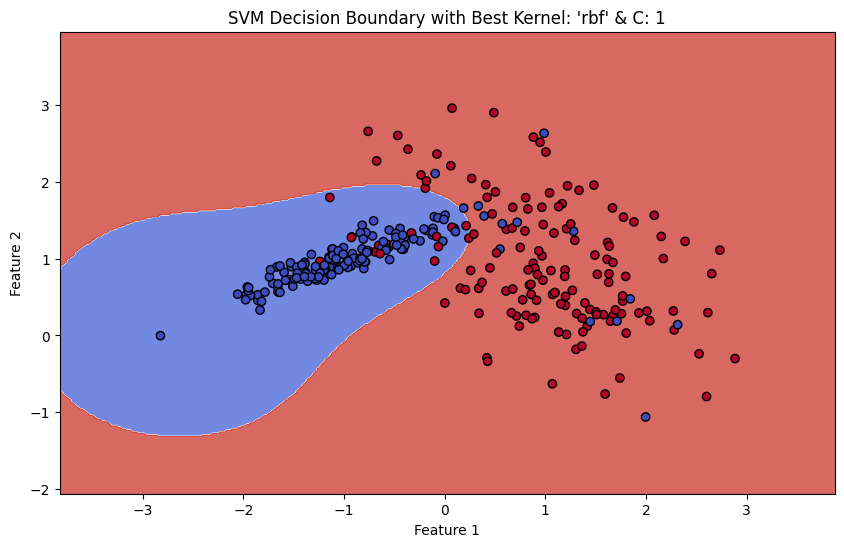

In [22]:
def plot_decision_boundary(X, y, model, title):
    """
    Plots the decision boundary of a trained model along with the data points.
    """
    # Create a mesh grid
    h = .02  # step size in the mesh
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    # Predict the class for each point in the mesh
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(10, 6))
    plt.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.8)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolors='k')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.title(title)
    plt.show()


plot_decision_boundary(
    X, y, best_svm,
    f"SVM Decision Boundary with Best Kernel: '{grid_search.best_params_['kernel']}' & C: {grid_search.best_params_['C']}"
)